In [7]:
# ============================================================
# Stand-alone notebook/script: ENSO/IOD experiments -> maps
#   - Loads idata
#   - Opens basin SST anom NetCDF to recover spatial coords
#   - Builds kept-space lat/lon in the SAME order as the model's "space"
#   - Plots Δ log(sigma) maps for each experiment
# ============================================================

import numpy as np
import pandas as pd
import xarray as xr
import arviz as az
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os

# ----------------------------
# User: mode experiments
# ----------------------------
EXPERIMENTS = [
    {"name": "El Niño (+1,0)",               "N": +1.0, "D":  0.0},
    {"name": "La Niña (-1,0)",               "N": -1.0, "D":  0.0},
    {"name": "pIOD (0,+1)",                  "N":  0.0, "D": +1.0},
    {"name": "nIOD (0,-1)",                  "N":  0.0, "D": -1.0},
    {"name": "Joint + (+1,+1)",              "N": +1.0, "D": +1.0},
    {"name": "Opposing El Niño (+1,-1)",     "N": +1.0, "D": -1.0},
    {"name": "Joint - (-1,-1)",              "N": -1.0, "D": -1.0},
    {"name": "Opposing La Niña (-1,+1)",     "N": -1.0, "D": +1.0},
    {"name": "Strong Opposing - (-1.5,+1.5)",       "N": -1.5, "D": +1.5},
]

# -----------------------------
# CONFIG 
# -----------------------------
BASIN = "gulf_aden"

OUT_IDATA = f"../data/sst/gpd_{BASIN}_roni_dmi_idata.nc"
BASIN_NC  = f"../data/sst/basin_anoms/era5_sst_anom_{BASIN}_1950_2025.nc"

# MUST MATCH the run that produced idata
Q = 0.95
MIN_EVENTS = 5

# plotting
MODE = "scatter"   # "scatter" (robust) or "regular" (pcolormesh grid)
EXTENT = [41.0, 56.5, 10.0, 17.5]      # e.g. [47, 57, 22, 31] or None EXTENT_ADEN = [41.0, 56.5, 10.0, 17.5] | EXTENT_REDSEA = [32.0, 44.5, 12.0, 30.5]
SHARE_COLORBAR = True

# -----------------------------
# Load posterior
# -----------------------------
idata = az.from_netcdf(OUT_IDATA)

# -----------------------------
# Recover spatial coordinates for idata.space
# -----------------------------
def recover_space_geometry(basin_nc, q, min_events, expected_space=None):
    """
    Rebuild (lon_space, lat_space) for the kept POT cells in the SAME order as used in model fitting.
    Also returns regular-grid helpers (lon2d, lat2d, space_to_ij) so you can pcolormesh if desired.

    expected_space: if provided, sanity check that recovered S_k matches idata.space
    """
    ds = xr.open_dataset(basin_nc)
    da = ds["sst_anom"]

    lat_name = "latitude" if "latitude" in da.coords else "lat"
    lon_name = "longitude" if "longitude" in da.coords else "lon"

    # lon shift [-180, 180] if needed (must match fit)
    if float(da[lon_name].max()) > 180:
        lon = da[lon_name]
        lon_new = ((lon + 180) % 360) - 180
        da = da.assign_coords({lon_name: lon_new}).sortby(lon_name)

    # ensure monthly MS (must match fit)
    t0 = pd.DatetimeIndex(pd.to_datetime(da["time"].values))
    is_month_start_midnight = (t0.day == 1).all() and (t0.hour == 0).all() and (t0.minute == 0).all()
    if not is_month_start_midnight:
        da = da.resample(time="MS").mean(skipna=True)

    # stack (time, space)
    da_st = da.stack(space=(lat_name, lon_name))

    # wet mask: non-NaN at first time
    valid_space = np.isfinite(da_st.isel(time=0).values)
    da_st = da_st.isel(space=valid_space)

    Y = da_st.values.astype("float32")  # (T, S_wet)

    # lat/lon per wet point in correct order
    space_index = da_st["space"].to_index()
    lats = np.array([x[0] for x in space_index], dtype="float32")
    lons = np.array([x[1] for x in space_index], dtype="float32")

    # POT keep mask (counts >= MIN_EVENTS)
    u = np.nanquantile(Y, q, axis=0).astype("float32")
    exc = Y > u[None, :]
    _, s_idx = np.where(exc)
    counts = np.bincount(s_idx, minlength=Y.shape[1])
    keep_space = counts >= min_events

    lats_k = lats[keep_space]
    lons_k = lons[keep_space]
    S_k = keep_space.sum()

    # regular-grid helpers
    lat_vals = da[lat_name].values.astype(float)
    lon_vals = da[lon_name].values.astype(float)
    lon2d, lat2d = np.meshgrid(lon_vals, lat_vals)

    lat_to_i = {v: i for i, v in enumerate(lat_vals)}
    lon_to_j = {v: j for j, v in enumerate(lon_vals)}

    # assumes exact matches (true for coordinates derived from same array)
    space_to_ij = np.column_stack([
        np.array([lat_to_i[v] for v in lats_k], dtype=int),
        np.array([lon_to_j[v] for v in lons_k], dtype=int),
    ])

    ds.close()

    if expected_space is not None and expected_space != S_k:
        raise ValueError(
            f"Recovered kept-space count S_k={S_k} does not match idata.space={expected_space}.\n"
            f"Set Q/MIN_EVENTS to match the original run, and ensure you're opening the same basin_nc."
        )

    return (lons_k.astype(float), lats_k.astype(float), lon2d, lat2d, space_to_ij)

S_idata = idata.posterior.sizes["space"]
lon_space, lat_space, lon2d, lat2d, space_to_ij = recover_space_geometry(
    BASIN_NC, Q, MIN_EVENTS, expected_space=S_idata
)

# -----------------------------
# Posterior helpers
# -----------------------------
def _stack_draws(da: xr.DataArray) -> xr.DataArray:
    if "chain" in da.dims and "draw" in da.dims:
        return da.stack(sample=("chain", "draw"))
    if "sample" in da.dims:
        return da
    raise ValueError(f"Unexpected dims for {da.name}: {da.dims}")

def get_posterior_coeffs(idata):
    post = idata.posterior
    a_s   = _stack_draws(post["a_s"])   
    bN_s  = _stack_draws(post["bN_s"])
    bD_s  = _stack_draws(post["bD_s"])
    bND_s = _stack_draws(post["bND_s"])
    return a_s, bN_s, bD_s, bND_s

def delta_sigma_K_draws(idata, N_val, D_val):
    """
    Returns Δσ (Kelvin) posterior draws per space with dims (sample, space).

    σ0 = exp(a_s)
    Δlogσ = bN_s*N + bD_s*D + bND_s*(N*D)
    Δσ = σ0 * (exp(Δlogσ) - 1)
    """
    a_s, bN_s, bD_s, bND_s = get_posterior_coeffs(idata)

    sigma0 = np.exp(a_s)  # (sample, space) in K
    dlog = (bN_s * N_val) + (bD_s * D_val) + (bND_s * (N_val * D_val))  # (sample, space)

    d_sigma = sigma0 * (np.exp(dlog) - 1.0)  # (sample, space) in K
    return d_sigma

def delta_log_sigma_map(idata, N_val, D_val):
    bN_s, bD_s, bND_s = get_posterior_coeffs(idata)
    ND_val = N_val * D_val
    dlog = (bN_s * N_val) + (bD_s * D_val) + (bND_s * ND_val)
    return dlog.mean(dim="sample")  # (space,)

# -----------------------------
# Plotting helpers
# -----------------------------
def add_map_features(ax, show_labels=False):
    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)
    ax.add_feature(cfeature.LAND, alpha=0.15)
    ax.add_feature(cfeature.OCEAN, alpha=0.05)

    gl = ax.gridlines(draw_labels=show_labels, linewidth=0.2, alpha=0.4)
    if show_labels:
        gl.top_labels = False
        gl.right_labels = False
    else:
        # no labels on other panels
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = False
        gl.bottom_labels = False


def basin_mean_and_hdi_K(dsigma_draws, hdi_prob=0.94):
    """
    dsigma_draws: (sample, space) in Kelvin
    Returns: mean, hdi_low, hdi_high (Kelvin)
    """
    basin_mean_draws = dsigma_draws.mean(dim="space")  # (sample,)
    mean_val = float(basin_mean_draws.mean().values)
    lo, hi = az.hdi(basin_mean_draws.values, hdi_prob=hdi_prob)
    return mean_val, float(lo), float(hi)



def delta_log_sigma_draws(idata, N_val, D_val):
    a_s, bN_s, bD_s, bND_s = get_posterior_coeffs(idata)
    ND_val = N_val * D_val
    return (bN_s * N_val) + (bD_s * D_val) + (bND_s * ND_val)  # (sample, space)


def build_field2d_from_space(field_space, lat2d, space_to_ij):
    ny, nx = lat2d.shape
    field2d = np.full((ny, nx), np.nan, dtype=float)
    for s in range(field_space.shape[0]):
        i, j = space_to_ij[s]
        field2d[i, j] = field_space[s]
    return field2d

def get_diverging_norm(values, vlim=None, pct=99):
    """
    Helper for symmetric diverging color limits around zero.
    values: array-like
    vlim: if provided, use +/- vlim
    pct: percentile for robust symmetric limits if vlim is None
    Returns: (vcenter, vlim)
    """
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return 0.0, 1.0

    if vlim is None:
        # robust limit: symmetric around 0 using a high percentile of |values|
        vlim = np.nanpercentile(np.abs(v), pct)
        if not np.isfinite(vlim) or vlim == 0:
            vlim = np.nanmax(np.abs(v))
            if not np.isfinite(vlim) or vlim == 0:
                vlim = 1.0

    return 0.0, float(vlim)

def run_and_plot_experiments(
        idata,
        experiments,
        lon2d,
        lat2d,
        space_to_ij,
        basin,
        extent=None,
        hdi_prob=0.94,
        cmap="RdBu_r",
        out_dir_base="../figures",
    ):
        out_dir = os.path.join(out_dir_base, f"roni_iod_{basin}_extremes")
        os.makedirs(out_dir, exist_ok=True)
    
        # shared color limits based on posterior-mean Δσ maps (K)
        mean_maps_space = []
        for exp in experiments:
            dsigma = delta_sigma_K_draws(idata, exp["N"], exp["D"])  # (sample, space)
            mean_maps_space.append(dsigma.mean(dim="sample").values) # (space,)
    
        all_means = np.concatenate([m.ravel() for m in mean_maps_space])
        _, global_vlim = get_diverging_norm(all_means, vlim=None)
        norm = mcolors.TwoSlopeNorm(vmin=-global_vlim, vcenter=0.0, vmax=global_vlim)
    
        fig, axes = plt.subplots(
            nrows=3, ncols=3,
            figsize=(13, 11),
            subplot_kw={"projection": ccrs.PlateCarree()},
            constrained_layout=True,
        )
        axes = axes.ravel()
        mappable = None
    
        for k, exp in enumerate(experiments):
            ax = axes[k]
            if extent is not None:
                ax.set_extent(extent, crs=ccrs.PlateCarree())
    
            # Δσ draws in K
            dsigma_draws = delta_sigma_K_draws(idata, exp["N"], exp["D"])
            basin_mean, lo, hi = basin_mean_and_hdi_K(dsigma_draws, hdi_prob=hdi_prob)
    
            # posterior mean map (space,)
            dsigma_mean_space = dsigma_draws.mean(dim="sample").values
            field2d = build_field2d_from_space(dsigma_mean_space, lat2d, space_to_ij)
    
            m = ax.pcolormesh(
                lon2d, lat2d, field2d,
                transform=ccrs.PlateCarree(),
                shading="auto",
                cmap=cmap,
                norm=norm,
            )
            mappable = m
    
            add_map_features(ax, show_labels=(k == 0))
            ax.set_title(exp["name"], fontsize=11)
    
            txt = (
                f"Basin mean Δσ: {basin_mean:+.3f} K\n"
                f"{int(hdi_prob*100)}% HDI: [{lo:+.3f}, {hi:+.3f}] K"
            )
            ax.text(
                0.02, 0.02, txt,
                transform=ax.transAxes,
                ha="left", va="bottom",
                fontsize=9,
                bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=3),
            )
    
        # hide unused axes if not exactly 9
        for kk in range(len(experiments), len(axes)):
            axes[kk].set_visible(False)
    
        cbar = fig.colorbar(mappable, ax=axes, orientation="vertical", shrink=0.9, pad=0.02)
        cbar.set_label("Δσ (K)")
    
        out_path = os.path.join(out_dir, f"roni_iod_{basin}_extremes_dsigmaK_3x3.png")
        fig.savefig(out_path, dpi=250, bbox_inches="tight")
        print("✅ saved:", out_path)
    
        plt.show()



✅ saved: ../figures/roni_iod_gulf_aden_extremes/roni_iod_gulf_aden_extremes_dsigmaK_3x3.png


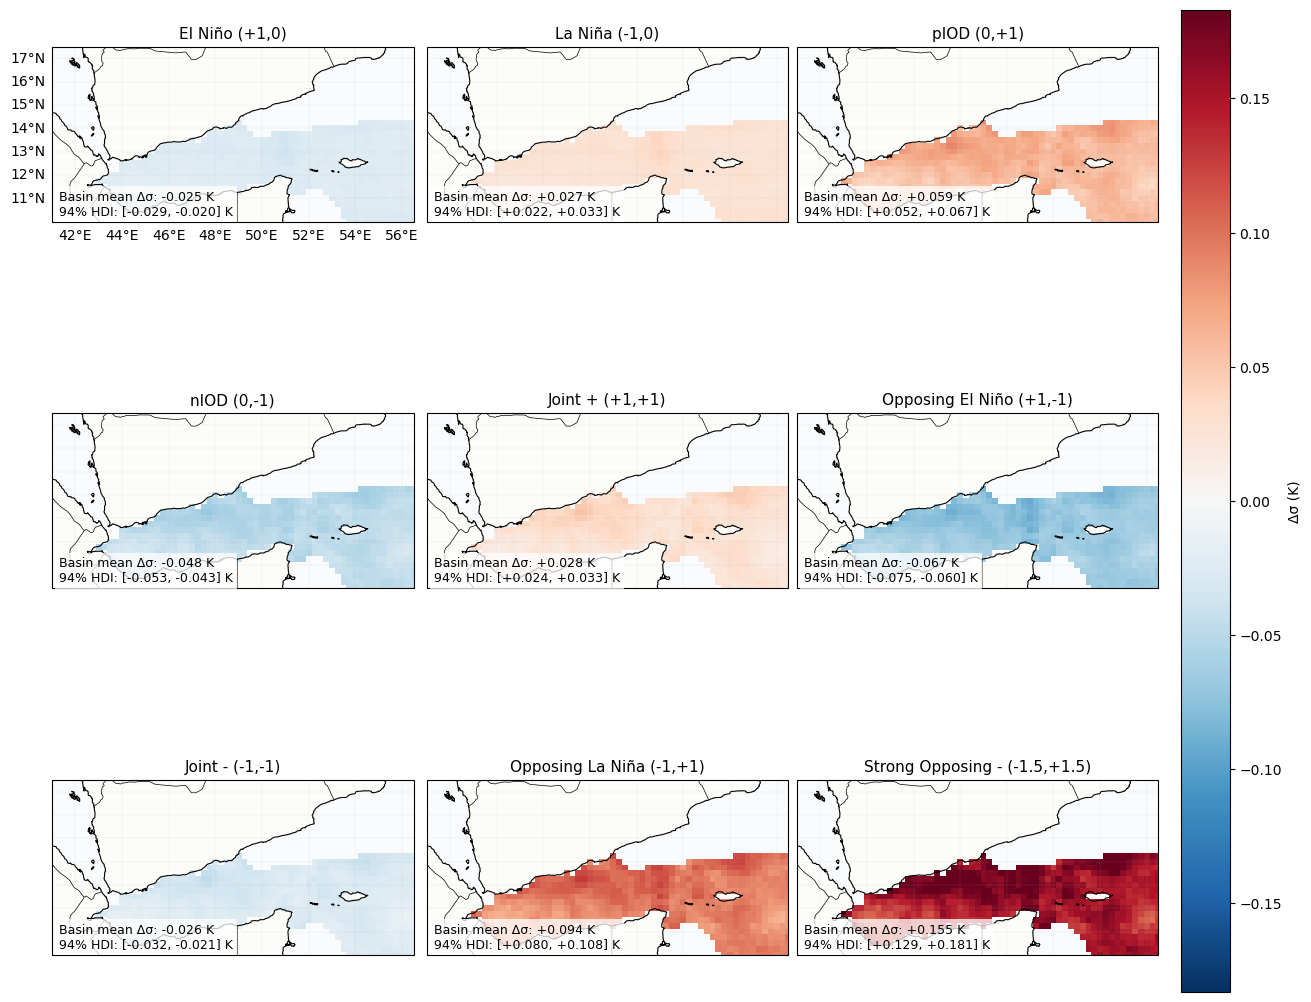

In [8]:
# -----------------------------
# Run
# -----------------------------
run_and_plot_experiments(
    idata,
    experiments=EXPERIMENTS,
    lon2d=lon2d,
    lat2d=lat2d,
    space_to_ij=space_to_ij,
    basin=BASIN,
    extent=EXTENT,
    hdi_prob=0.94,
    out_dir_base="../figures",
)